In [19]:
import os
import pandas as pd
import numpy as np
from pandas import read_csv 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
current_dir = os.getcwd()
path = os.path.join(current_dir, "metric.csv")
document = read_csv(path)

In [3]:
print(document.head)

<bound method NDFrame.head of            task      dataset  llm_summarizer  summarization_prompt  \
0          task      dataset  llm_summarizer  summarization_prompt   
1    REGRESSION  196_autoMpg          llama4             zero_shot   
2    REGRESSION  196_autoMpg          llama4             zero_shot   
3    REGRESSION  196_autoMpg          llama4             zero_shot   
4    REGRESSION  196_autoMpg          llama4             zero_shot   
..          ...          ...             ...                   ...   
359        task      dataset  llm_summarizer  summarization_prompt   
360        task      dataset  llm_summarizer  summarization_prompt   
361        task      dataset  llm_summarizer  summarization_prompt   
362        task      dataset  llm_summarizer  summarization_prompt   
363        task      dataset  llm_summarizer  summarization_prompt   

     judging_llm  judging_prompt        metric  score      label  
0    judging_llm  judging_prompt        metric  score      lab

In [6]:
print(document.info)

<bound method DataFrame.info of            task      dataset  llm_summarizer  summarization_prompt  \
0          task      dataset  llm_summarizer  summarization_prompt   
1    REGRESSION  196_autoMpg          llama4             zero_shot   
2    REGRESSION  196_autoMpg          llama4             zero_shot   
3    REGRESSION  196_autoMpg          llama4             zero_shot   
4    REGRESSION  196_autoMpg          llama4             zero_shot   
..          ...          ...             ...                   ...   
359        task      dataset  llm_summarizer  summarization_prompt   
360        task      dataset  llm_summarizer  summarization_prompt   
361        task      dataset  llm_summarizer  summarization_prompt   
362        task      dataset  llm_summarizer  summarization_prompt   
363        task      dataset  llm_summarizer  summarization_prompt   

     judging_llm  judging_prompt        metric  score      label  
0    judging_llm  judging_prompt        metric  score      l

In [14]:
df = pd.DataFrame(document)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   task                  364 non-null    object
 1   dataset               364 non-null    object
 2   llm_summarizer        364 non-null    object
 3   summarization_prompt  364 non-null    object
 4   judging_llm           364 non-null    object
 5   judging_prompt        364 non-null    object
 6   metric                364 non-null    object
 7   score                 364 non-null    object
 8   label                 364 non-null    object
dtypes: object(9)
memory usage: 25.7+ KB


In [13]:
df.describe()

,task,dataset,llm_summarizer,summarization_prompt,judging_llm,judging_prompt,metric,score,label
count,364,364,364,364,364,364,364,364,364
unique,4,4,3,5,3,2,6,4,4
top,CLASSIFICATION,299_libras_move,deepseek-r1:14b,Few_shot,llama4,judge_new,metric,5,Very Good
freq,145,145,175,90,230,300,64,124,124


In [15]:
#Comverting the dataframe to a pythonlist for easier manipulation
df.columns.tolist()

['task',
 'dataset',
 'llm_summarizer',
 'summarization_prompt',
 'judging_llm',
 'judging_prompt',
 'metric',
 'score',
 'label']

In [16]:
#Checking Missing Values
df.isnull().sum()

task                    0
dataset                 0
llm_summarizer          0
summarization_prompt    0
judging_llm             0
judging_prompt          0
metric                  0
score                   0
label                   0
dtype: int64

In [17]:
#Checking for duplicate value
df.nunique()

task                    4
dataset                 4
llm_summarizer          3
summarization_prompt    5
judging_llm             3
judging_prompt          2
metric                  6
score                   4
label                   4
dtype: int64

In [21]:
train_x = df.drop(columns=['label'])

In [22]:
sns.set_palette("Pastel1")
plt.figure(figsize=(10,6))
sns.pairplot(df)
plt.suptitle('Pair Plot for DataFrame')
plt.show

ValueError: No variables found for grid columns.

<Figure size 1000x600 with 0 Axes>

### Evaluating different prompt on a particular LLM

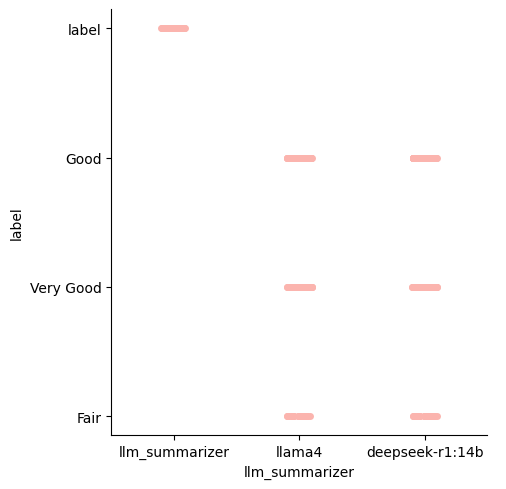

In [26]:
sns.catplot(data=df, x="llm_summarizer", y="label")

/home/nguenang/miniconda3/envs/envTest_experiment/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 85.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/nguenang/miniconda3/envs/envTest_experiment/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 70.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/nguenang/miniconda3/envs/envTest_experiment/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 92.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/nguenang/miniconda3/envs/envTest_experiment/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 83.3% of the points cannot be placed; you may want to decrease the size of the markers or use strip

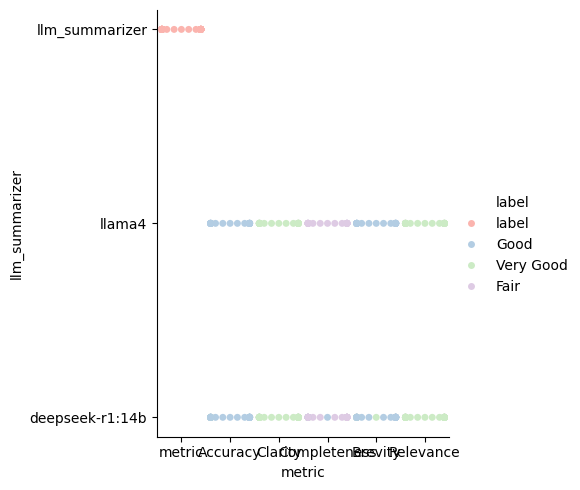

In [27]:
sns.catplot(data=df, x="metric", y="llm_summarizer", hue="label", kind="swarm")

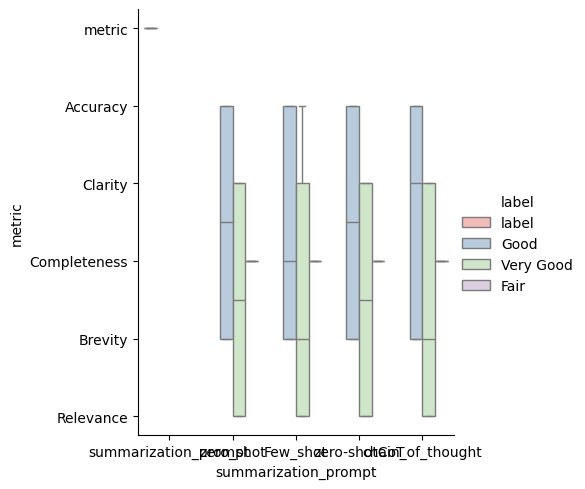

In [29]:

sns.catplot(data=df, x="summarization_prompt", y="metric", hue="label", kind="box")


In [30]:
# sns.catplot(data=df.query("llm != llama"), x="size", y="label", native_scale=True)

In [36]:
df["llm_summarizer"] = pd.Categorical(df["llm_summarizer"], ordered=True)
df["metric"] = pd.Categorical(df["metric"], ordered=True)

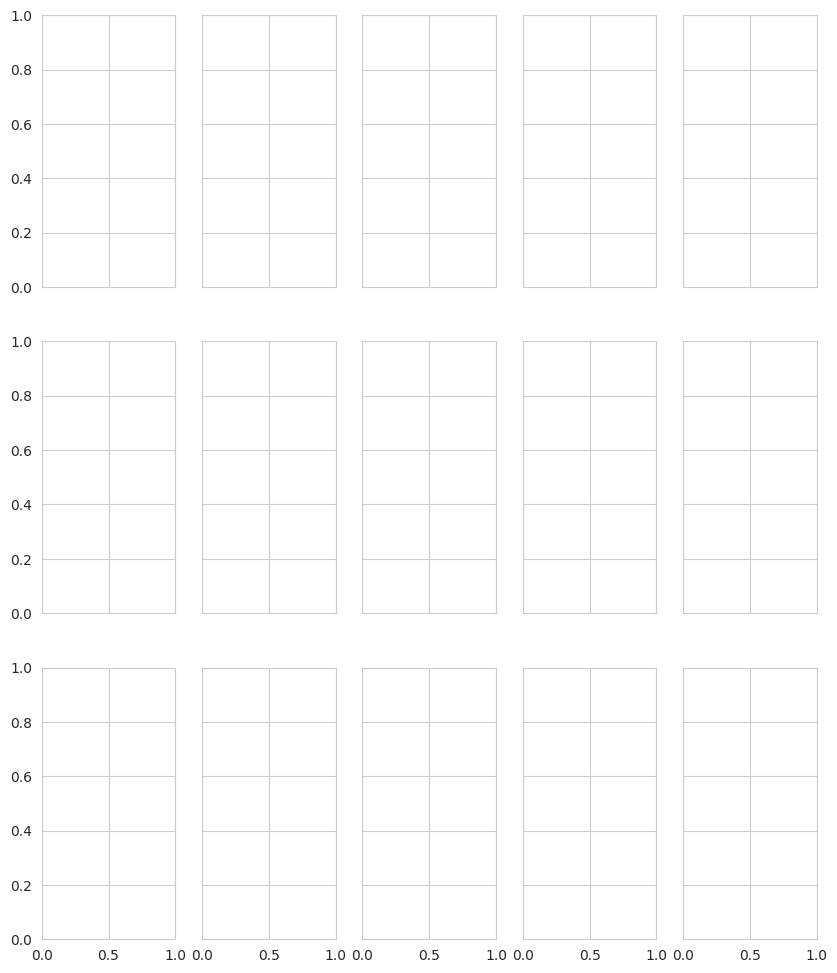

In [39]:
sns.set_style("whitegrid")
colors = {
    "Accuracy": "#1f77b4",
    "Clarity": "#4b23c2",
    "Completeness": "#ff7f0e",
    "Brevity": "#2ca02c ",
    "Relevance": "#4dd3c4e",
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=5,
    figsize=(10,12),
    sharex=True,
    sharey=True
    
)



In [42]:
# -------------------------------------------------
# Draw each subplot
# -------------------------------------------------
for i, model in enumerate(df["llm_summarizer"]):
    for j, metric in enumerate(df["metric"]):

        
        ax = axes[i, j]
        subset = df[(df["llm_summarizer"] == model) & (df["metric"] == metric)]

        if subset.empty:
            continue

        # Bubble scatter
        ax.scatter(
            subset["x_value"],
            subset["score"],
            s=subset["weight"] * 3,
            alpha=0.6,
            color=colors[metric],
            edgecolor="none"
        )

        # Regression line
        sns.regplot(
            x="x_value",
            y="score",
            data=subset,
            ax=ax,
            scatter=False,
            color="black",
            ci=95,
            line_kws={"linewidth": 2}
        )

        # Titles and labels
        if i == 0:
            ax.set_title(metric, fontsize=11, pad=10)

        if j == 0:
            ax.set_ylabel(model, fontsize=10)
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")
        ax.set_ylim(1, 5.2)
        
        
   

KeyError: 'x_value'

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------
# Load data
# -------------------------------------------------
df = pd.read_csv("metric.csv")

# Remove header-like first row if present
df = df[df["metric"] != "metric"].copy()

# Ensure numeric scores
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df = df.dropna(subset=["score"])

# -------------------------------------------------
# Rename columns for clarity
# -------------------------------------------------
df = df.rename(columns={
    "llm_summarizer": "model"
})

In [44]:

# -------------------------------------------------
# Order models and metrics (edit if needed)
# -------------------------------------------------
model_order = sorted(df["model"].unique())
metric_order = sorted(df["metric"].unique())

df["model"] = pd.Categorical(df["model"], categories=model_order, ordered=True)
df["metric"] = pd.Categorical(df["metric"], categories=metric_order, ordered=True)

# -------------------------------------------------
# Create x-axis index per model–metric
# -------------------------------------------------
df = df.sort_values(["model", "metric"]).copy()
df["x_value"] = df.groupby(["model", "metric"]).cumcount() + 1

# -------------------------------------------------
# Bubble size = frequency of same score
# -------------------------------------------------
df["weight"] = (
    df.groupby(["model", "metric", "score"])["score"]
      .transform("count")
)

/tmp/ipykernel_33196/3123801714.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["x_value"] = df.groupby(["model", "metric"]).cumcount() + 1
/tmp/ipykernel_33196/3123801714.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["model", "metric", "score"])["score"]


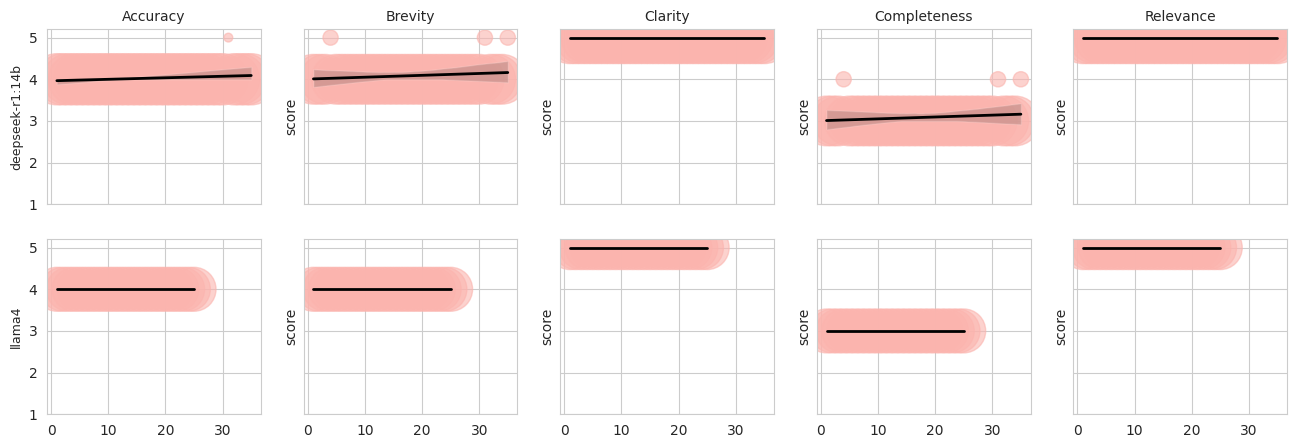

In [46]:
# -------------------------------------------------
# Plot
# -------------------------------------------------
sns.set_style("whitegrid")

fig, axes = plt.subplots(
    nrows=len(model_order),
    ncols=len(metric_order),
    figsize=(3.2 * len(metric_order), 2.5 * len(model_order)),
    sharex=True,
    sharey=True
)

for i, model in enumerate(model_order):
    for j, metric in enumerate(metric_order):

        ax = axes[i, j] if len(model_order) > 1 else axes[j]
        subset = df[(df["model"] == model) & (df["metric"] == metric)]

        if subset.empty:
            ax.axis("off")
            continue

        # Bubble scatter
        ax.scatter(
            subset["x_value"],
            subset["score"],
            s=subset["weight"] * 40,
            alpha=0.6
        )

        # Regression line
        sns.regplot(
            x="x_value",
            y="score",
            data=subset,
            scatter=False,
            ax=ax,
            ci=95,
            color="black",
            line_kws={"linewidth": 2}
        )

        # Titles / labels
        if i == 0:
            ax.set_title(metric, fontsize=10)
        if j == 0:
            ax.set_ylabel(model, fontsize=9)

        ax.set_ylim(1, 5.2)
        ax.set_xlabel("")

In [48]:
# -------------------------------------------------
# Global labels
# -------------------------------------------------
fig.supxlabel("Evaluation Instances", fontsize=11)
fig.supylabel("Score", fontsize=11)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [31]:
label = ['','','','']